# 08 · Did the loyalty rollout work? — difference-in-differences (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We launched the loyalty app in some stores, not others. Revenue in the
launch stores went up — but revenue went up *everywhere* (a seasonal tide lifts all boats). Did the app
add anything **net of that tide**, and is it worth rolling out to the whole chain?

### The idea: two differences

**Difference-in-differences (DiD)** is the workhorse of quasi-experiments. It takes **two** differences
and subtracts them:

$$\text{DiD} = \underbrace{(\bar Y^{\text{treated}}_{\text{after}} - \bar Y^{\text{treated}}_{\text{before}})}_{\text{treated change}} - \underbrace{(\bar Y^{\text{control}}_{\text{after}} - \bar Y^{\text{control}}_{\text{before}})}_{\text{control change}}.$$

The first difference (treated after − before) contains the app effect **plus** the seasonal tide; the
second (control after − before) is the tide **alone**. Subtracting removes the tide and leaves the app
effect. It's the same "compare like with like" logic as everywhere else, applied *across time*.

### The one assumption everything rests on: parallel trends

DiD is valid only if, **absent the app**, treated and control stores would have moved *in parallel* — the
control's change is a fair stand-in for what the treated stores' change would have been. This is untestable
after launch (we never see the treated stores' no-app future), but the **pre-launch trends are the
evidence**: if the two groups moved together *before* the app, parallel trends is credible. We check this
formally with an **event study** (the effect period-by-period) and falsify with a **placebo** (a fake
launch date in the pre-period, which should show ≈ 0 effect).

> **On real data.** Swap in your **own store/region panel** — one row per store per period with revenue, a
> treated/control flag, and a period index. The textbook public example is **Card & Krueger (1994)** on
> minimum wage and employment (fast-food restaurants in New Jersey vs Pennsylvania). One warning we
> *demonstrate live* in Step 7: if stores adopt at **different times** ("staggered rollout"), naive DiD can
> be badly biased and you need modern estimators (Callaway–Sant'Anna, Sun–Abraham).

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 23; LAUNCH = 12; TRUE = 400.0

## 2 · Simulate a ground truth

40 stores, half get the loyalty app at week 12. Every store shares a seasonal pattern and has its
own baseline; the app adds a **true €400/store/week**. Treated and control move in **parallel**
before launch by construction — so DiD should recover €400, and the event study should show a flat
pre-trend.


In [2]:
df, true_effect = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, true_effect=TRUE, seed=SEED)
print(f"TRUE effect = €{true_effect:.0f}/store/week  ·  {df['unit'].nunique()} stores, {df['t'].nunique()} weeks, launch week {LAUNCH}")
df.head()

TRUE effect = €400/store/week  ·  40 stores, 24 weeks, launch week 12


,store,unit,t,week,group,post_treatment,post,revenue
0,store_00,0,0,0,1,False,0,1071.613014
1,store_00,0,1,1,1,False,0,1066.597066
2,store_00,0,2,2,1,False,0,1019.187212
3,store_00,0,3,3,1,False,0,834.246887
4,store_00,0,4,4,1,False,0,1030.278745


## 3 · Identify — the 2×2 estimand, parallel trends, and the event study

DiD estimates $\beta_3$ in
$Y=\beta_0+\beta_1\text{group}+\beta_2\text{post}+\beta_3(\text{group}\times\text{post})+\varepsilon$,
which equals the difference of the two before/after differences. **Key assumption — parallel
trends:** absent the app, treated and control revenue would have moved together. It's untestable
post-launch, but the **event study** — the treated-minus-control gap in *each* period relative to
launch — is the evidence: flat and ≈0 before launch supports it; a jump at launch is the effect.


Pre-launch gaps average €22 (≈0 supports parallel trends); post-launch gaps jump toward €400.


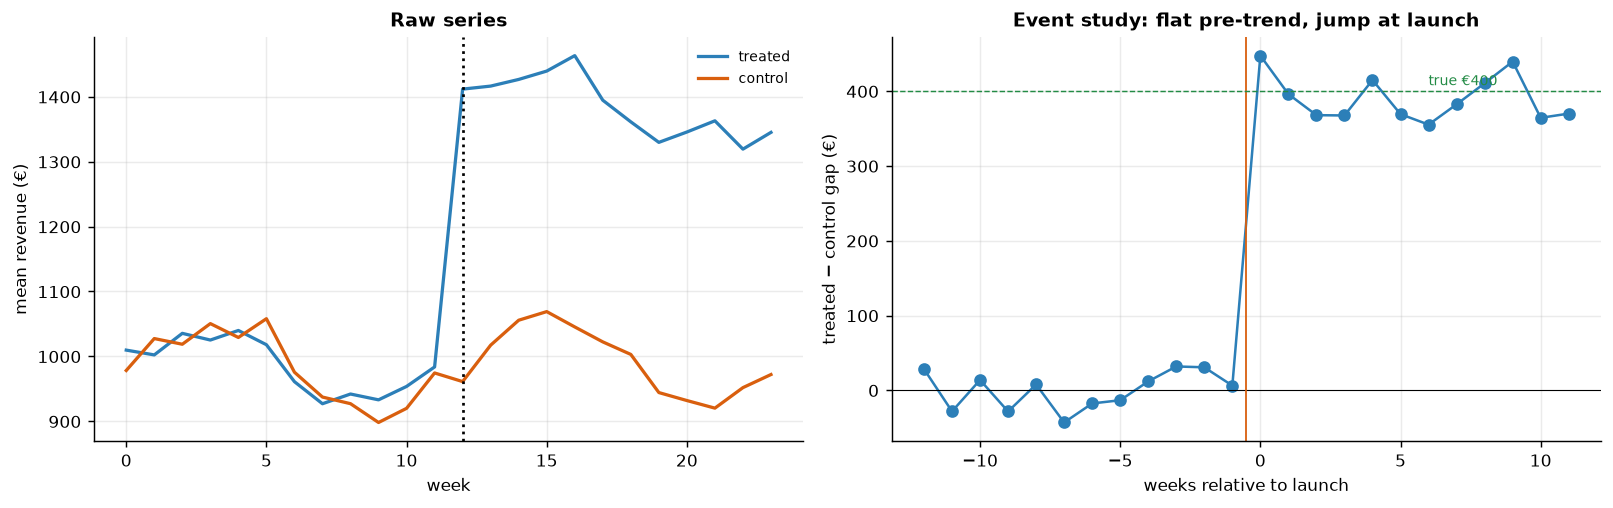

In [3]:
# event study: per-week treated-minus-control gap, recentred on the pre-launch mean gap
piv = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
gap = (piv[1] - piv[0])
gap_centered = gap - gap[gap.index < LAUNCH].mean()
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
g = df.groupby(["t","group"])["revenue"].mean().unstack()
ax[0].plot(g.index, g[1], color=plots.BLUE, lw=1.8, label="treated"); ax[0].plot(g.index, g[0], color=plots.ORANGE, lw=1.8, label="control")
ax[0].axvline(LAUNCH, color="k", ls=":"); ax[0].set_xlabel("week"); ax[0].set_ylabel("mean revenue (€)"); ax[0].set_title("Raw series"); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(gap_centered.index - LAUNCH, gap_centered.values, color=plots.BLUE, marker="o", lw=1.4)
ax[1].axhline(0, color="k", lw=0.6); ax[1].axvline(-0.5, color=plots.ORANGE, lw=1)
ax[1].axhline(TRUE, color=plots.GREEN, ls="--", lw=0.8); ax[1].text(6, TRUE+8, f"true €{TRUE:.0f}", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("weeks relative to launch"); ax[1].set_ylabel("treated − control gap (€)"); ax[1].set_title("Event study: flat pre-trend, jump at launch")
fig.tight_layout()
pre_gap = gap_centered[gap_centered.index < LAUNCH].abs().mean()
print(f"Pre-launch gaps average €{pre_gap:.0f} (≈0 supports parallel trends); post-launch gaps jump toward €{TRUE:.0f}.")

**How to read the event study (right panel).** This is the single most important plot in a DiD analysis.
Each dot is the treated-minus-control revenue gap in one week, relative to launch (week 0). The story we
*want* to see, and do: the dots are **flat and hovering around zero *before* launch** — that's the visual
evidence for parallel trends, the assumption the whole method rests on — and then they **jump to ≈ €400 at
launch** and stay there. A rising or falling pre-launch trend would have been a red flag that the two groups
were already diverging, and we'd have had to abandon DiD for synthetic control (notebook 07). The left panel
shows the raw series so you can see both groups riding the same seasonal wave.

## 4 · Estimate — Bayesian difference-in-differences

We now put a number and an interval on that jump. One implementation detail: CausalPy's
`DifferenceInDifferences` expects the classic **2×2 form** — exactly one "before" and one "after"
observation per unit — so we first collapse each store's 24 weekly points into a pre-launch mean and a
post-launch mean. The estimate is the `group × post` interaction coefficient $\beta_3$, i.e. the DiD.


In [4]:
agg = df.groupby(["unit","group","post_treatment"])["revenue"].mean().reset_index()
agg["t"] = agg["post_treatment"].astype(int).astype(float)
# CausalPy 0.8.1's LinearRegression ships FIXED priors (beta ~ N(0,50), sigma ~ HalfNormal(1))
# scaled for O(1) data; on revenue ~ €1000 they fight the data and shrink the effect low (and
# too-narrow). We standardize revenue for the fit, then back-transform the effect to euros.
rev_mu, rev_sd = agg["revenue"].mean(), agg["revenue"].std()
agg["revenue_z"] = (agg["revenue"] - rev_mu) / rev_sd
result = est.did(agg, formula="revenue_z ~ 1 + group*post_treatment", fast=FAST)
impact = np.asarray(result.causal_impact).ravel() * rev_sd    # standardized effect -> euros
print(f"DiD effect €{impact.mean():.0f}/store/week (true €{true_effect:.0f})  ·  "
      f"90% CI [€{np.quantile(impact,0.05):.0f}, €{np.quantile(impact,0.95):.0f}]")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


DiD effect €389/store/week (true €400)  ·  90% CI [€275, €515]


## 5 · Validate — 2×2 cross-check and a placebo test

Cross-check the Bayesian estimate against the hand-computed 2×2. With revenue **standardized** before
the fit (so CausalPy's default O(1)-scaled priors don't shrink a €400 effect sitting on €1000 revenue),
the two now **agree** and both land on the planted €400 with the truth inside the interval. Then
**falsify**: run DiD on the *pre-period only*, splitting it into a fake "before/after" at week 6. There
was no treatment then, so the placebo effect should be ≈ 0 — a large one would mean our design
manufactures effects.

Bayesian €389  ·  2×2 €390  ·  true €400  ·  placebo (no real effect) €17


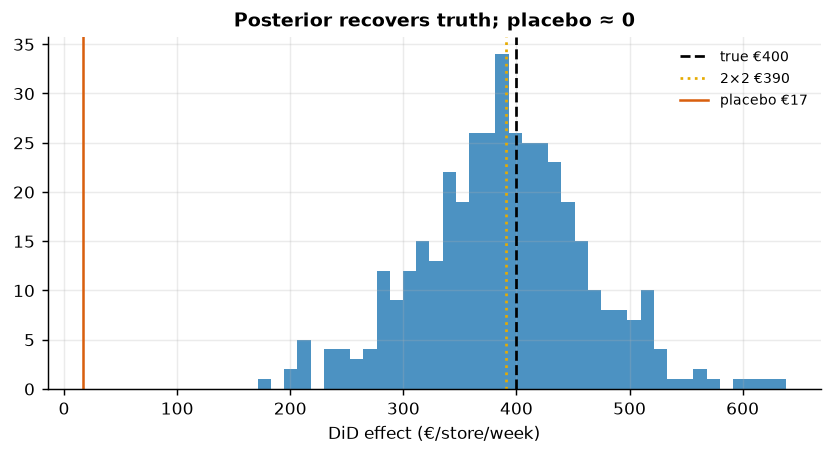

In [5]:
m = df.groupby(["group","post"])["revenue"].mean()
did_2x2 = (m[1,1]-m[1,0]) - (m[0,1]-m[0,0])
# placebo: pre-period only, fake launch at week 6
pre = df[df.t < LAUNCH].copy(); pre["fake_post"] = (pre.t >= 6).astype(int)
mp = pre.groupby(["group","fake_post"])["revenue"].mean()
placebo = (mp[1,1]-mp[1,0]) - (mp[0,1]-mp[0,0])
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(impact, bins=40, color=plots.BLUE, alpha=0.85)
ax.axvline(true_effect, color="k", ls="--", label=f"true €{true_effect:.0f}")
ax.axvline(did_2x2, color=plots.GOLD, ls=":", label=f"2×2 €{did_2x2:.0f}")
ax.axvline(placebo, color=plots.ORANGE, lw=1.4, label=f"placebo €{placebo:.0f}")
ax.set_xlabel("DiD effect (€/store/week)"); ax.set_title("Posterior recovers truth; placebo ≈ 0"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"Bayesian €{impact.mean():.0f}  ·  2×2 €{did_2x2:.0f}  ·  true €{true_effect:.0f}  ·  placebo (no real effect) €{placebo:.0f}")

## 6 · Decide, in euros — the rollout case

In [6]:
N_STORES, WEEKS, APP_COST = 500, 52, 120.0
net = impact - APP_COST
annual = net * N_STORES * WEEKS
p_worth = (net > 0).mean()
# break-even: what running cost could the app bear?
be_cost = np.quantile(impact, 0.05)
print(f"Net €{net.mean():.0f}/store/week  ·  projected annual value €{annual.mean():,.0f} "
      f"[90% €{np.quantile(annual,0.05):,.0f}, €{np.quantile(annual,0.95):,.0f}]")
print(f"P(app pays) {p_worth:.2f}  → " + ("ROLL OUT" if p_worth>0.9 else "pilot further"))
print(f"Break-even: the app stays profitable up to a running cost of ~€{be_cost:.0f}/store/week (5th pct of the effect).")

Net €269/store/week  ·  projected annual value €7,002,587 [90% €4,021,073, €10,270,170]
P(app pays) 1.00  → ROLL OUT
Break-even: the app stays profitable up to a running cost of ~€275/store/week (5th pct of the effect).


## 7 · Caveats — and the staggered-adoption trap, demonstrated

**Parallel trends is the whole ballgame** and untestable post-launch; a diverging pre-trend kills the
design (use synthetic control, nb 07). **No spillover** between nearby stores. But the subtlest trap is
**staggered adoption**: when units adopt at *different* times, naive two-way fixed-effects DiD uses
already-treated units as controls ("forbidden comparisons") and can put **negative weights** on some
effects (Goodman-Bacon), biasing the estimate even when every true effect is positive. We show it live:


Naive TWFE €177 vs true average post-treatment effect €400 — bias -223. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.


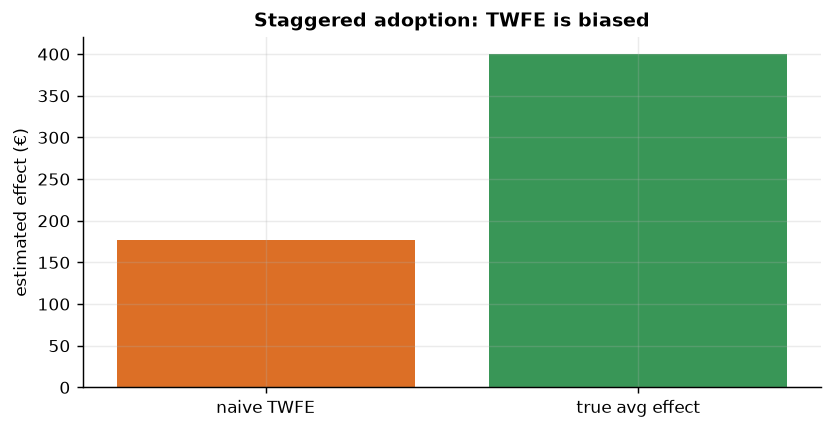

In [7]:
# staggered rollout: cohort A treated at week 8, cohort B at week 16, with a GROWING true effect
rng = np.random.default_rng(1); NS, NW = 60, 28
rows = []
for s in range(NS):
    cohort = "A" if s < NS//2 else "B"; g = 8 if cohort=="A" else 16
    base = rng.normal(1000, 120); season = 60*np.sin(2*np.pi*np.arange(NW)/12)
    # dynamic effect that GROWS after adoption (this is what breaks naive TWFE)
    te = np.where(np.arange(NW) >= g, 200 + 25*(np.arange(NW)-g), 0.0)
    rev = base + season + te + rng.normal(0, 60, NW)
    for t in range(NW):
        rows.append({"unit": s, "cohort": cohort, "t": t, "post": int(t>=g), "rev": rev[t], "true_te": te[t]})
sd = pd.DataFrame(rows)
# naive TWFE (single post dummy) vs the true average post-treatment effect
import numpy as _np
Xd = pd.get_dummies(sd["unit"], prefix="u").astype(float); Xt = pd.get_dummies(sd["t"], prefix="t").astype(float)
D = _np.column_stack([_np.ones(len(sd)), sd["post"].values, Xd.values[:,1:], Xt.values[:,1:]])
twfe = _np.linalg.lstsq(D, sd["rev"].values, rcond=None)[0][1]
true_avg = sd.loc[sd.post==1, "true_te"].mean()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(["naive TWFE","true avg effect"], [twfe, true_avg], color=[plots.ORANGE, plots.GREEN], alpha=0.9)
ax.set_ylabel("estimated effect (€)"); ax.set_title("Staggered adoption: TWFE is biased"); fig.tight_layout()
print(f"Naive TWFE €{twfe:.0f} vs true average post-treatment effect €{true_avg:.0f} — "
      f"bias {twfe-true_avg:+.0f}. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.")